In [28]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# Monte Carlo Simulations of our System

## Code 

### Create the system

In [29]:
def wrap_angle(x):
    '''
    Wrap angle between -pi and pi
    Inputs:
        x: angle
    Outputs:
        wrapped angle
    '''

    return (x + np.pi/6) % (np.pi/3) - np.pi/6

def theta_flatten(theta, indices):
    '''
    Flatten theta array
    Inputs:
        theta: 2D
        indices
    Outputs:
        theta_flat: 1D
    '''

    return np.array([theta[i, j] for (i, j) in indices])

class Lattice:
    '''
    Lattice class to hold lattice properties
    Attributes:
        L: size
        indices: list of (i,j) coordinates
        voisins: list of neighbors for each (i,j)
    '''

    def __init__(self, L, rho=1.0):
        self.L = L
        self.rho = rho
        self.indices = np.array([(i, j) for i in range(L) for j in range(L)])
        self.voisins = np.zeros((L * L, 6, 2), dtype=int)
        for idx, (i, j) in enumerate(self.indices):
            if i % 2 == 0:
                vois = np.array([
                    ((i + 1) % L, j),
                    ((i - 1) % L, j),
                    (i, (j + 1) % L),
                    (i, (j - 1) % L),
                    ((i + 1) % L, (j - 1) % L),
                    ((i - 1) % L, (j - 1) % L)
                ])
            else:
                vois = np.array([
                    ((i + 1) % L, j),
                    ((i - 1) % L, j),
                    (i, (j + 1) % L),
                    (i, (j - 1) % L),
                    ((i + 1) % L, (j + 1) % L),
                    ((i - 1) % L, (j + 1) % L)
                ])
            self.voisins[idx] = vois
        self.theta = np.random.uniform(-np.pi/6, np.pi/6, size=(L, L))

    def get_xy_positions(self, i, j):
        '''
        Get (x,y) of the (i,j) point 
        Inputs:
            i, j
        Outputs:
            x, y
        '''

        aire = self.L * self.L / self.rho
        distance = np.sqrt(aire) / self.L
        x = j * distance + (i % 2) * (distance / 2)
        y = i * (distance * np.sqrt(3) / 2)
        return x, y
    
    def hamiltonien(self, epsilon, gamma, A):
        '''
        Compute the Hamiltonian of the system
        Inputs:
            epsilon, gamma, A: parameters
        Outputs:
            Hamiltonian
        '''

        H_0 = (epsilon/self.rho) * np.sum(theta_flatten(self.theta, self.indices)**2)
        H_int = 0.0
        for idx, (i, j) in enumerate(self.indices):
            for (ni, nj) in self.voisins[idx]:
                dtheta = np.abs(wrap_angle(self.theta[i, j] - self.theta[ni, nj]))
                H_int += dtheta * (A - np.log(max(dtheta, 1e-12)))
        H_int = (gamma / 3 * np.sqrt(self.rho)) * H_int
        return H_0 + H_int

    def dhamiltonien(self, new_theta, idx, epsilon, gamma, A):
        '''
        Compute the change in Hamiltonian when one theta is changed
        Inputs:
            new_theta
            idx: index of the changed theta in indices
            epsilon, gamma, A: parameters
        Outputs:
            Change in Hamiltonian
        '''

        i, j = self.indices[idx]
        dH_0 = (epsilon/self.rho) * (new_theta**2 - self.theta[i, j]**2)
        dH_int = 0.0
        for (ni, nj) in self.voisins[idx]:
            dtheta_old = np.abs(wrap_angle(self.theta[i, j] - self.theta[ni, nj]))
            dtheta_new = np.abs(wrap_angle(new_theta - self.theta[ni, nj]))
            dH_int += dtheta_new * (A - np.log(max(dtheta_new, 1e-12))) - dtheta_old * (A - np.log(max(dtheta_old, 1e-12)))
        dH_int = (gamma / 3 * np.sqrt(self.rho)) * dH_int
        return dH_0 + dH_int

### Monte Carlo Simulation

In [30]:
class AdaptiveMetropolis:
    def __init__(self, delta_init=0.5, target_acceptance=0.5, tune_interval=100_000, growth_factor=1.05, shrink_factor=0.95, min_delta=1e-3, max_delta=np.pi/6):
        self.delta = delta_init
        self.target_acceptance = target_acceptance
        self.tune_interval = tune_interval
        self.growth_factor = growth_factor
        self.shrink_factor = shrink_factor
        self.min_delta = min_delta
        self.max_delta = max_delta
        self.attempts = 0
        self.acceptances = 0

    def metropolis_step(self, lattice, epsilon, gamma, A, beta, tune=True):
        '''
        Perform one Metropolis step with adaptive delta
        Inputs:
            lattice: Lattice object
            epsilon, gamma, A: parameters
            beta
        Outputs:
            accepted: bool
        '''
        N = len(lattice.indices)
        idx = np.random.randint(N)
        i, j = lattice.indices[idx]
        new_theta = wrap_angle(lattice.theta[i, j] + np.random.uniform(-self.delta, self.delta))
        delta_H = lattice.dhamiltonien(new_theta, idx, epsilon, gamma, A)

        self.attempts += 1
        if delta_H < 0 or np.random.rand() < np.exp(-beta * delta_H):
            lattice.theta[i, j] = new_theta
            self.acceptances += 1

        if tune and self.attempts % self.tune_interval == 0:
            acceptance_rate = self.acceptances / max(1, self.attempts)
            if acceptance_rate < self.target_acceptance - 0.05:
                self.delta = max(self.min_delta, self.delta * self.shrink_factor)
            elif acceptance_rate > self.target_acceptance + 0.05:
                self.delta = min(self.max_delta, self.delta * self.growth_factor)
            self.attempts = 0
            self.acceptances = 0

    def overrelaxation_sweep(self, lattice):
        '''
        Perform one overrelaxation
        Inputs:
            lattice: Lattice object
        '''

        for idx, (i, j) in enumerate(lattice.indices):
            sx = 0.0
            sy = 0.0
            for (ni, nj) in lattice.voisins[idx]:
                sx += np.cos(6 * lattice.theta[ni, nj])
                sy += np.sin(6 * lattice.theta[ni, nj])
            if sx == 0 and sy == 0:
                continue
            
            phi6 = np.arctan2(sy, sx)
            theta_i = lattice.theta[i, j]
            theta_new = wrap_angle(2 * (phi6 / 6) - theta_i)
            lattice.theta[i, j] = theta_new
    
class Simulation:
    def __init__(self, L, T, epsilon, gamma, A, rho=1.0, n_thermal=50_000, n_steps=10_000, measure_interval=1000, overrelax_interval=10_000, tune_delta=True):
        self.L = L
        self.T = T
        self.epsilon = epsilon
        self.gamma = gamma
        self.A = A
        self.beta = 1.0 / T
        self.rho = rho
        self.n_thermal = n_thermal
        self.n_steps = n_steps
        self.measure_interval = measure_interval
        self.lattice = Lattice(L, rho)
        self.adaptive_metropolis = AdaptiveMetropolis()
        self.overrelax_interval = overrelax_interval
        self.tune_delta = tune_delta
        self.energies = []

    def compute_correlation(self):
        '''
        Compute the correlation function of the lattice
        Outputs:
            r : distance
            G : correlation function
        '''
        
        aire = self.L * self.L / self.rho
        d = np.sqrt(aire) / self.L

        psi6 = np.exp(1j * 6 * self.lattice.theta)
        corr = np.fft.ifft2(np.fft.fft2(psi6) * np.conj(np.fft.fft2(psi6))).real
        corr /= (self.L * self.L)
        corr = np.fft.fftshift(corr)
        corr /= corr[self.L // 2, self.L // 2]

        ny, nx = corr.shape
        y, x = np.indices((ny, nx))
        cx, cy = (nx - 1) / 2, (ny - 1) / 2
        dx = (x - cx + nx//2) % nx - nx//2
        dy = (y - cy + ny//2) % ny - ny//2
        r = np.sqrt((dx*d)**2 + (dy*d*np.sqrt(3)/2)**2)

        n_bins = self.L // 2
        r_max = np.min([np.max(r), self.L * d / 2])
        bins = np.linspace(0, r_max, n_bins + 1)
        r_vals = 0.5 * (bins[:-1] + bins[1:])
        G_vals = np.zeros(n_bins)

        for i in range(n_bins):
            mask = (r >= bins[i]) & (r < bins[i + 1])
            if np.any(mask):
                G_vals[i] = np.mean(corr[mask])

        r_vals = np.insert(r_vals, 0, 0.0)
        G_vals = np.insert(G_vals, 0, 1.0)
        return r_vals, np.abs(G_vals)
    
    def plot_lattice(self):
        x_positions = []
        y_positions = []
        for (i, j) in self.lattice.indices:
            x, y = self.lattice.get_xy_positions(i, j)
            x_positions.append(x)
            y_positions.append(y)

        plt.figure(figsize=(8, 6))
        plt.scatter(x_positions, y_positions, c=theta_flatten(self.lattice.theta, self.lattice.indices), cmap='hsv', s=20, marker='h')
        plt.colorbar(label=r'$\theta$ (rad)')
        plt.title(rf'Hexagonal Lattice L={self.L}, $T={self.T:.2e}$')
        plt.xlabel(r'$x$')
        plt.ylabel(r'$y$')

    def plot_correlation(self, r, G):
        plt.figure(figsize=(8, 6))
        plt.plot(r, G, label='Simulation Data')

        if self.gamma == 0.0:
            G_hexatic = np.exp(-18 * self.rho * self.T / self.epsilon)
            plt.axhline(G_hexatic, color='r', linestyle='--', label='Hexatic Phase Prediction')
        else:
            rmin = r[0]
            rmax = r[-1] / 2
            mask = (r > rmin) & (r < rmax)
            coef_power_decay, cov_power_decay = np.polyfit(np.log(r[mask]), np.log(G[mask]), 1, cov=True)
            eta6 = -coef_power_decay[0]
            eta6_err = np.sqrt(cov_power_decay[0, 0])

            rmin = r[0]
            rmax = r[-1]
            mask = (r > rmin) & (r < rmax)
            coef_expo_decay, cov_expo_decay = np.polyfit(r[mask], np.log(G[mask]), 1, cov=True)
            xi6 = -1 / coef_expo_decay[0]
            xi6_err = xi6**2 * np.sqrt(cov_expo_decay[0, 0])

            r0, G0 = r[mask][0], G[mask][0]
            plt.plot(r[1:], G0 * (r[1:]/r0)**(-eta6), linestyle='--', label=rf'Power-law fit: $\eta_6={eta6:.3f} \pm {eta6_err:.3f}$')
            plt.plot(r, G0 * np.exp(- (r - r0) / xi6), linestyle=':', label=rf'Exponential fit: $\xi_6={xi6:.2f} \pm {xi6_err:.2f}$')

        plt.title(rf'Correlation Function at $T={self.T:.2e}$, $L={self.L}$')
        plt.xlabel(r'$r$')
        plt.ylabel(r'$G_6(r)$')
        plt.ylim(0, 1.1)
        plt.legend()
        plt.grid()

    def plot_energy(self):
        plt.figure(figsize=(8, 6))
        plt.plot(np.arange(len(self.energies)) * (self.n_thermal // 10), self.energies)
        plt.title(rf'Energy per Spin at $T={self.T:.2e}$, $L={self.L}$')
        plt.xlabel('Monte Carlo Steps')
        plt.ylabel(r'$E/N$')
        plt.grid()

    def one_step(self, step, tune=True):
        '''
        Perform one simulation step (Metropolis + Overrelaxation)
        '''

        if step % self.overrelax_interval == 0:
            self.adaptive_metropolis.overrelaxation_sweep(self.lattice)
        else:
            self.adaptive_metropolis.metropolis_step(self.lattice, self.epsilon, self.gamma, self.A, self.beta, tune=tune)

    def run(self, path):
        '''
        Run the Monte Carlo simulation
        '''
        
        display(Markdown(f"## Running Simulation at T={self.T:.2e}, L={self.L}"))

        for step in range(self.n_thermal + 1):
            self.one_step(step, tune=self.tune_delta)
            if step % (self.n_thermal // 10) == 0:
                energy = self.lattice.hamiltonien(self.epsilon, self.gamma, self.A) / (self.L * self.L)
                self.energies.append(energy)
        
        rs, Gs = [], []

        for step in range(self.n_steps + 1):
            self.one_step(step, tune=False)
            if step % self.measure_interval == 0:
                r, G = self.compute_correlation()
                rs.append(r)
                Gs.append(G)

        rate = (self.adaptive_metropolis.acceptances /
                max(1, self.adaptive_metropolis.attempts))
        
        display(Markdown(f"### Final Acceptance Rate: {rate:.3f}, Delta: {self.adaptive_metropolis.delta:.3f}"))
        self.plot_lattice()
        plt.savefig(f"{path}/Final_Lattice_T{self.T:.2e}_L{self.L}.pdf")
        plt.close()
        self.plot_energy()
        plt.savefig(f"{path}/Energy_Evolution_T{self.T:.2e}_L{self.L}.pdf")
        plt.show()
        r = np.mean(np.array(rs), axis=0)
        G = np.mean(np.array(Gs), axis=0)
        self.plot_correlation(r, G)
        plt.savefig(f"{path}/Correlation_Function_T{self.T:.2e}_L{self.L}.pdf")
        plt.show()

## Large grains Simulation

In [31]:
epsilon = 1.0
gamma = 0.0
rho = 1.0
A = 1.0
T = []

L=32
n_thermal=10**6
n_steps=10**3
measure_interval=10**2
overrelax_interval=10**4

for temp in T:
    sim = Simulation(L, temp, epsilon, gamma, A, rho, n_thermal, n_steps, measure_interval, overrelax_interval)
    sim.run(path='FiguresLargeGrain')

## Small Grain Simulation 

## Running Simulation at T=1.00e-05, L=64

### Final Acceptance Rate: 0.019, Delta: 0.189

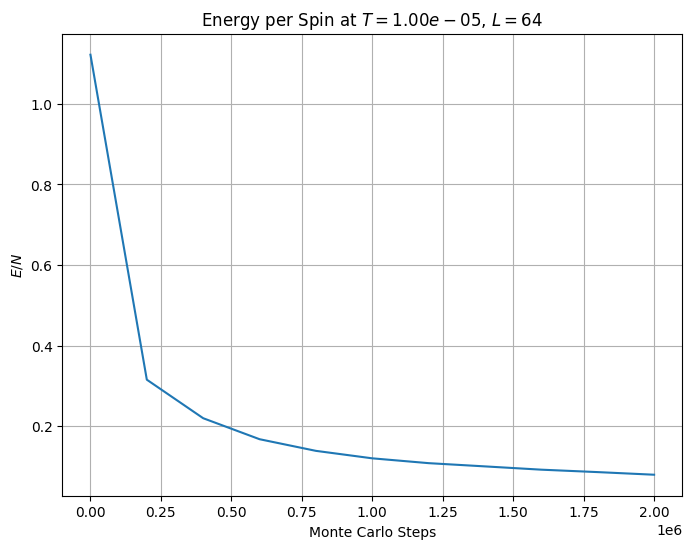

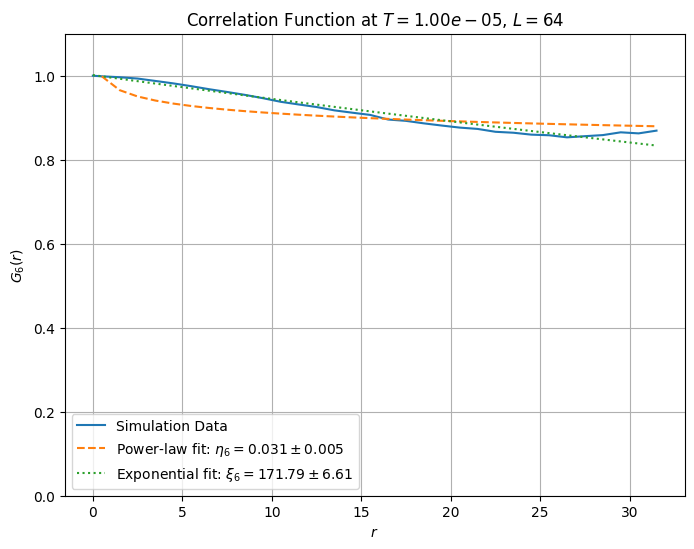

## Running Simulation at T=1.00e-02, L=64

### Final Acceptance Rate: 0.036, Delta: 0.189

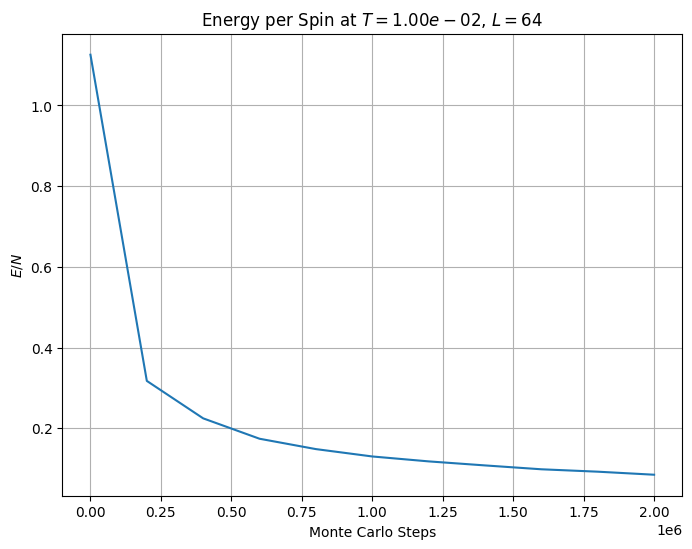

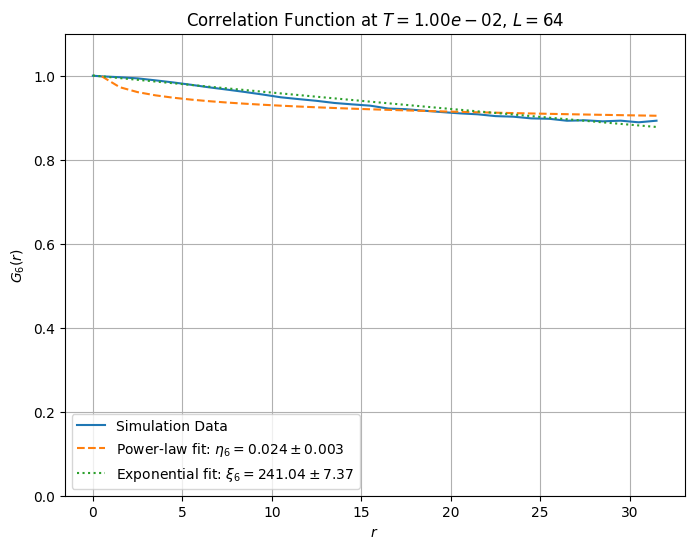

## Running Simulation at T=5.00e-02, L=64

### Final Acceptance Rate: 0.110, Delta: 0.189

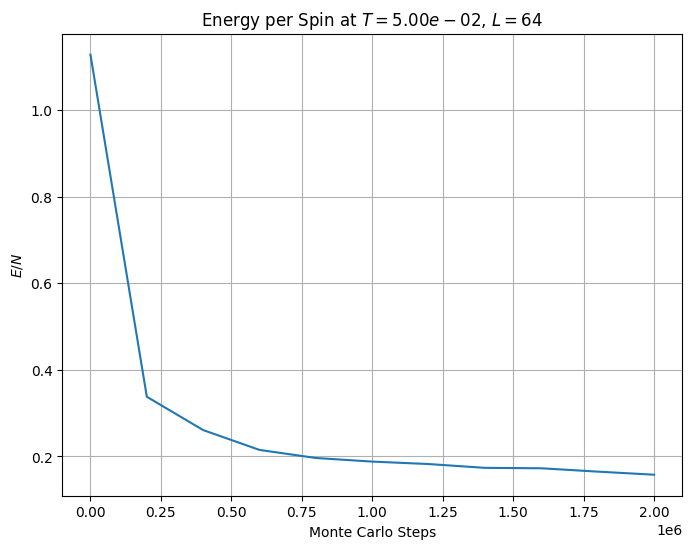

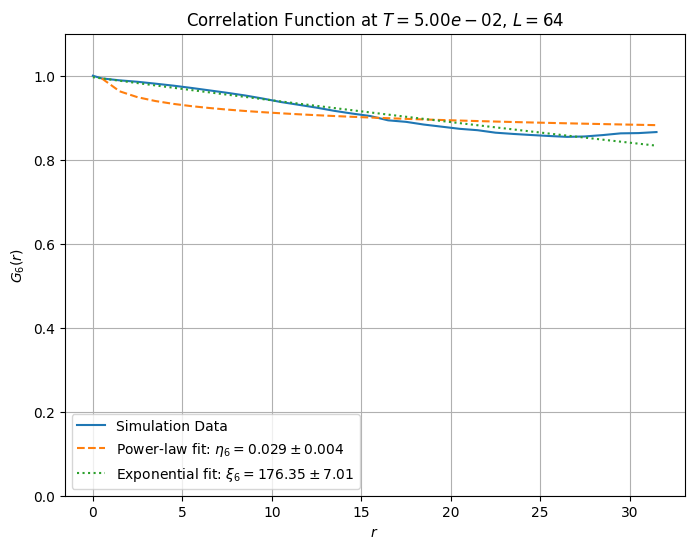

## Running Simulation at T=1.00e-01, L=64

### Final Acceptance Rate: 0.267, Delta: 0.189

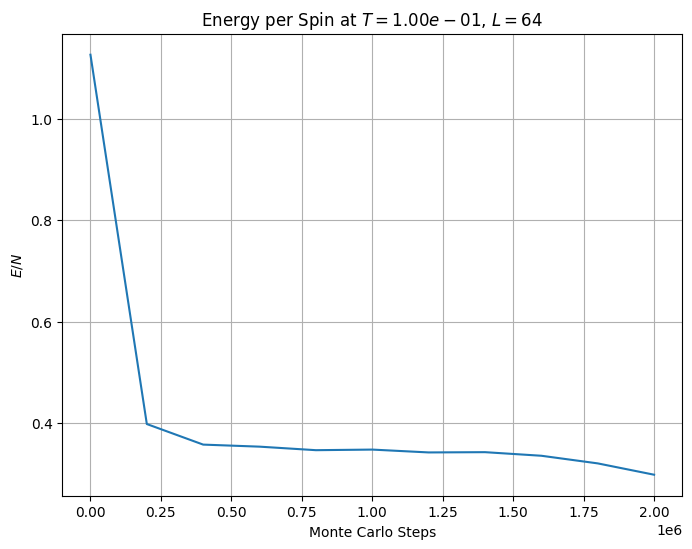

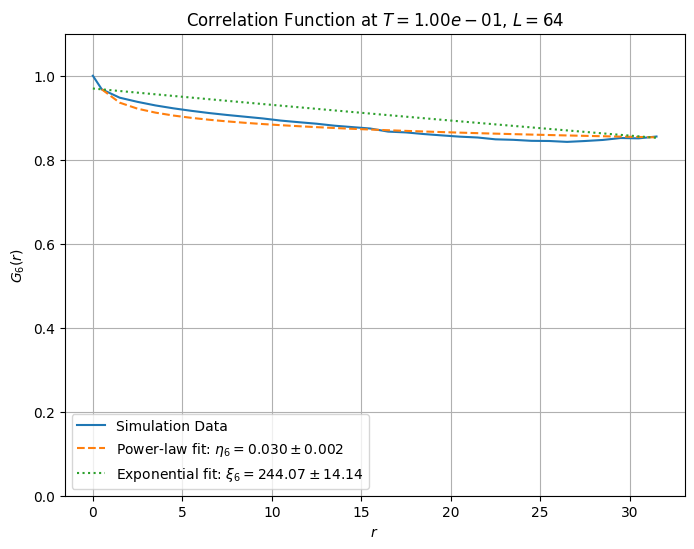

## Running Simulation at T=1.20e-01, L=64

### Final Acceptance Rate: 0.327, Delta: 0.189

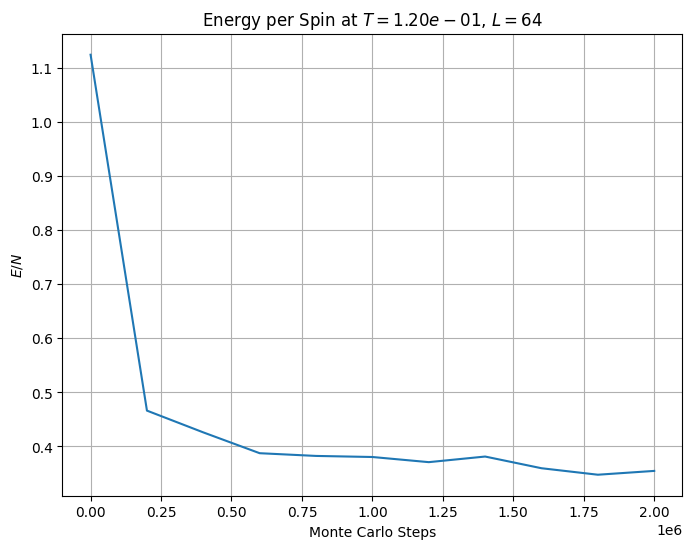

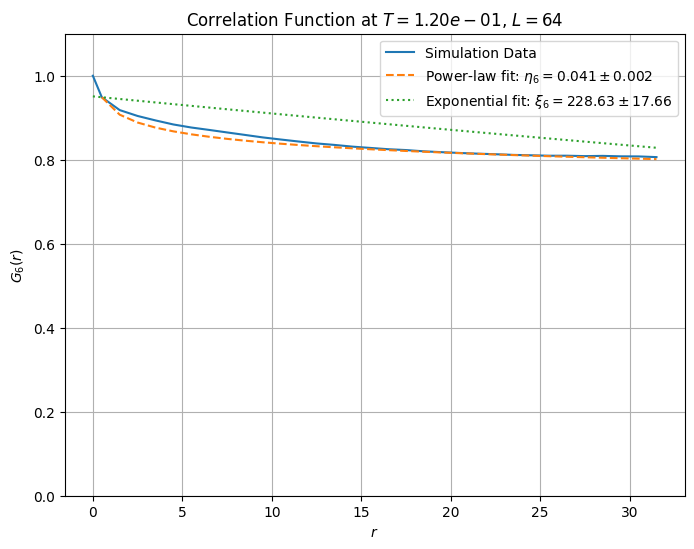

## Running Simulation at T=1.50e-01, L=64

### Final Acceptance Rate: 0.432, Delta: 0.189

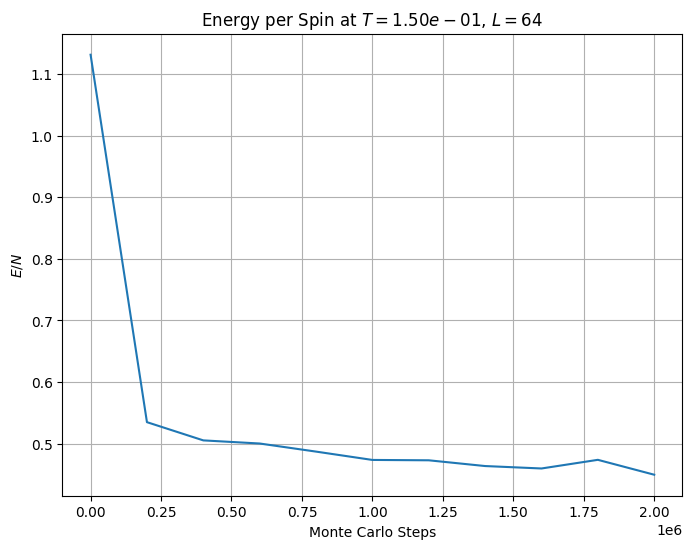

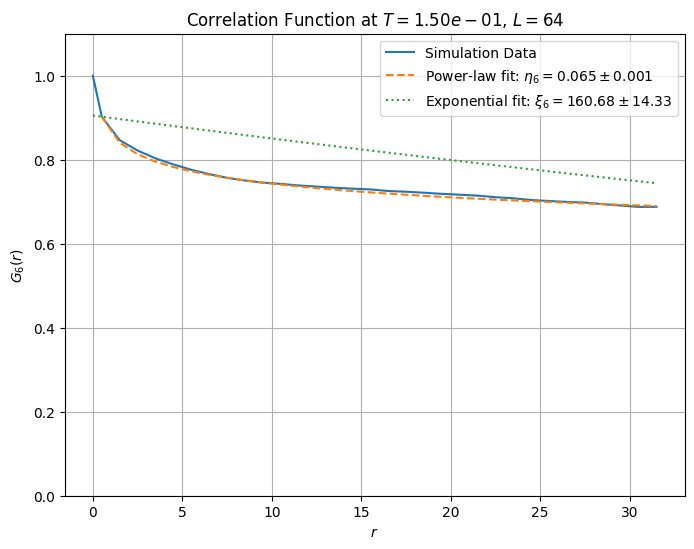

## Running Simulation at T=1.70e-01, L=64

### Final Acceptance Rate: 0.469, Delta: 0.209

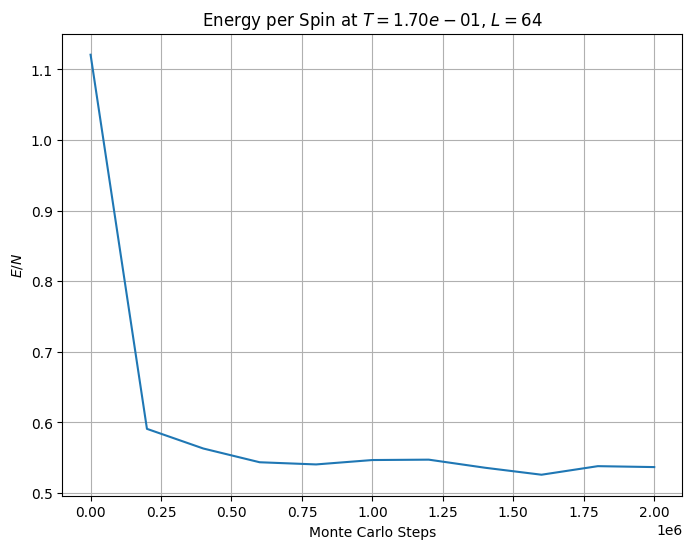

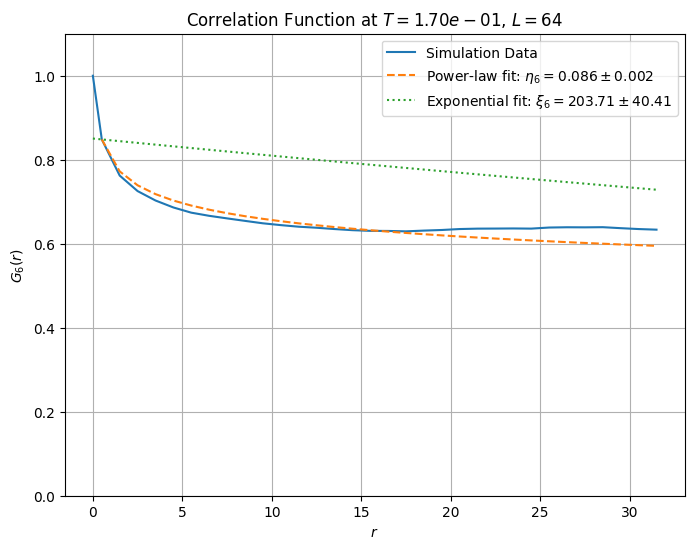

## Running Simulation at T=1.80e-01, L=64

### Final Acceptance Rate: 0.460, Delta: 0.244

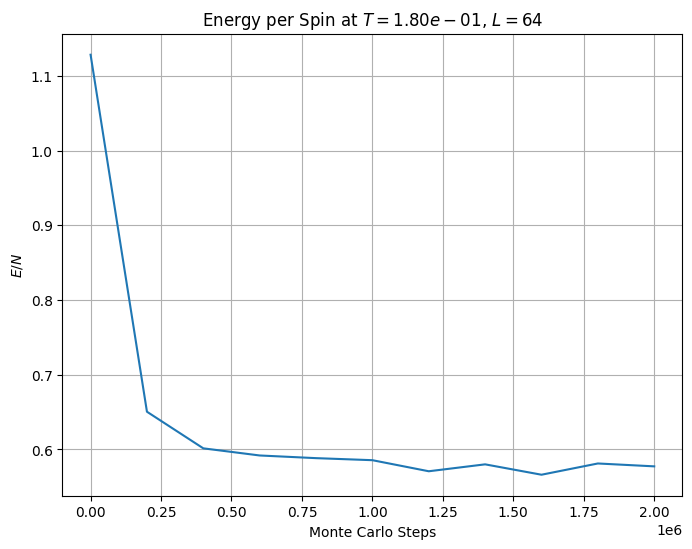

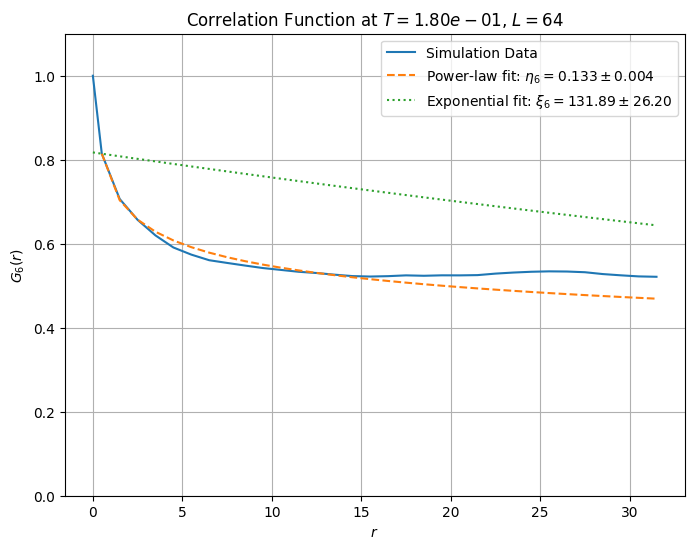

## Running Simulation at T=1.90e-01, L=64

### Final Acceptance Rate: 0.464, Delta: 0.270

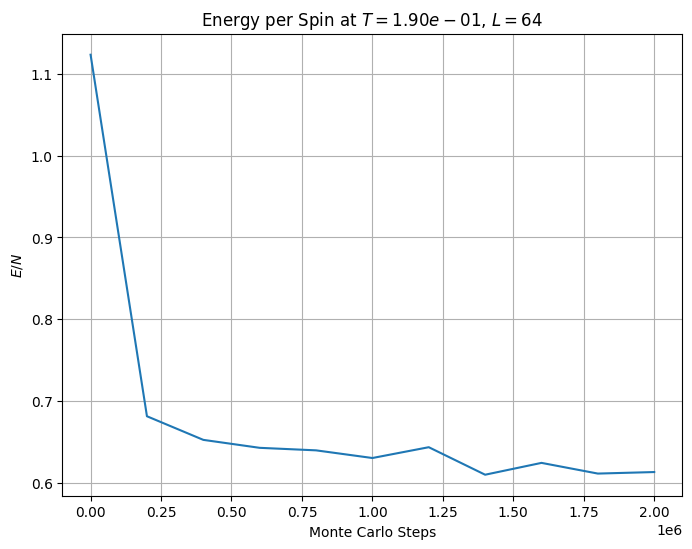

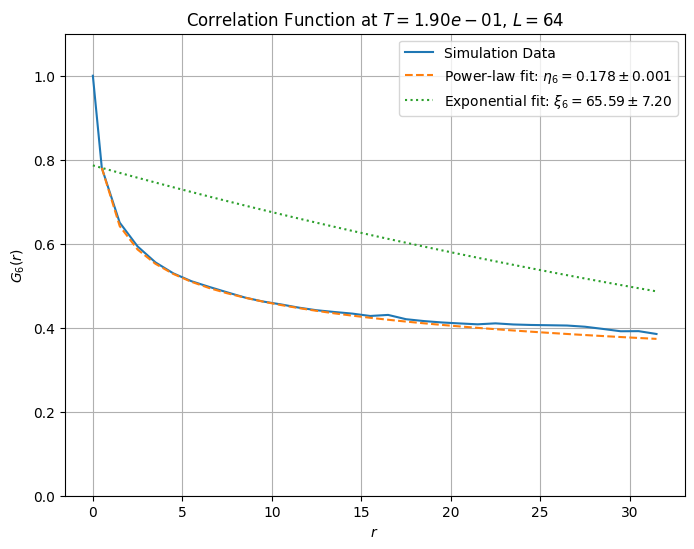

## Running Simulation at T=2.00e-01, L=64

### Final Acceptance Rate: 0.464, Delta: 0.315

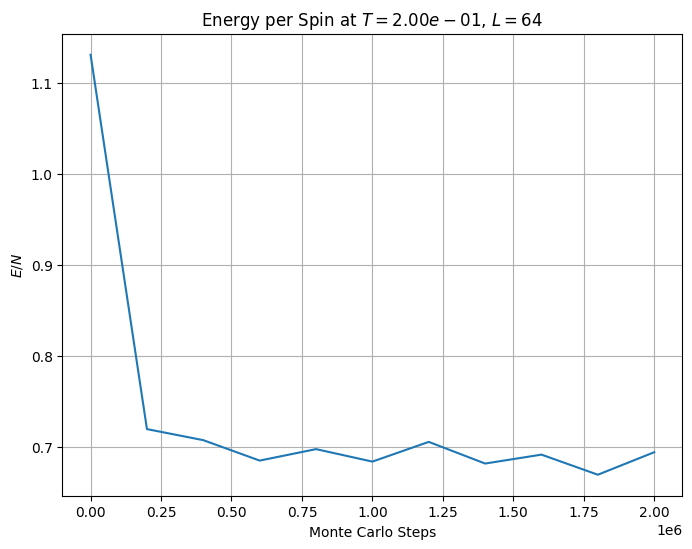

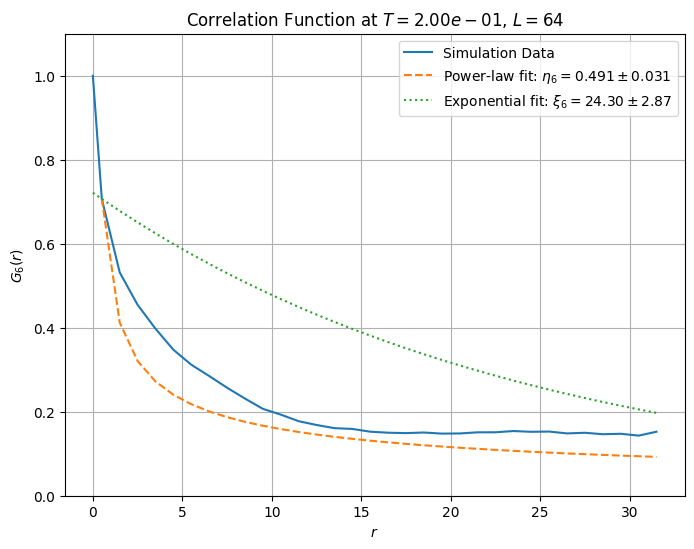

## Running Simulation at T=2.10e-01, L=64

### Final Acceptance Rate: 0.467, Delta: 0.349

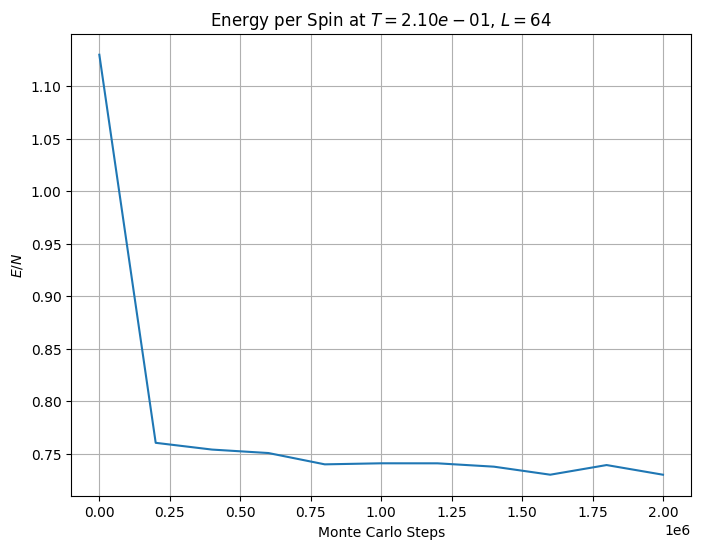

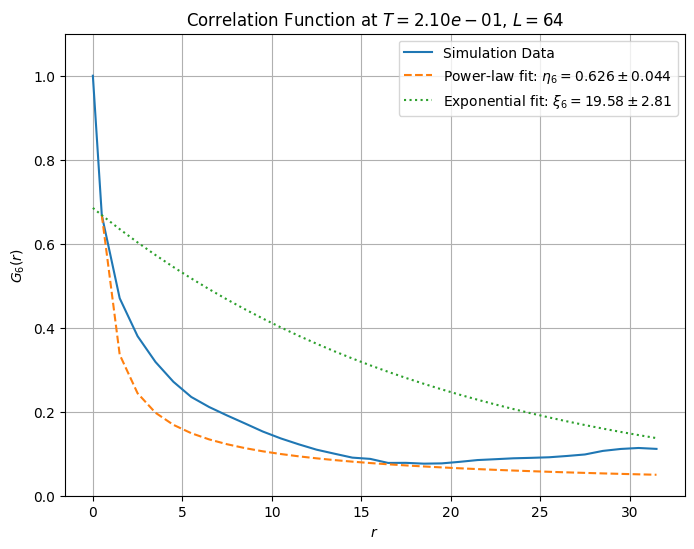

## Running Simulation at T=2.50e-01, L=64

### Final Acceptance Rate: 0.506, Delta: 0.524

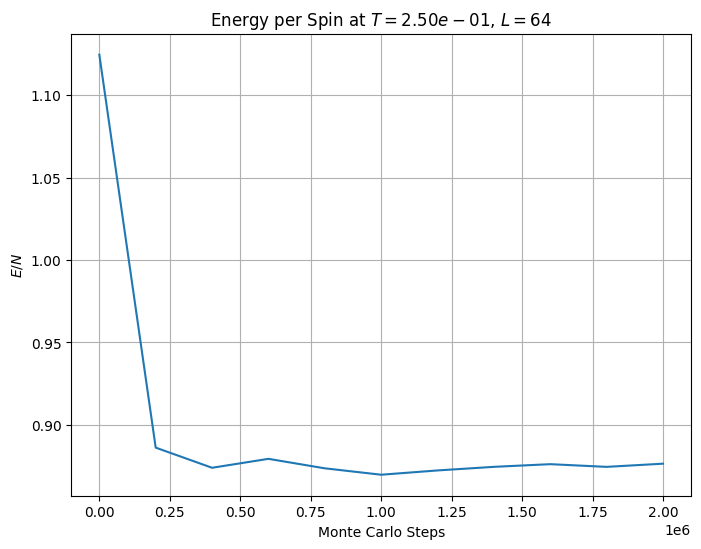

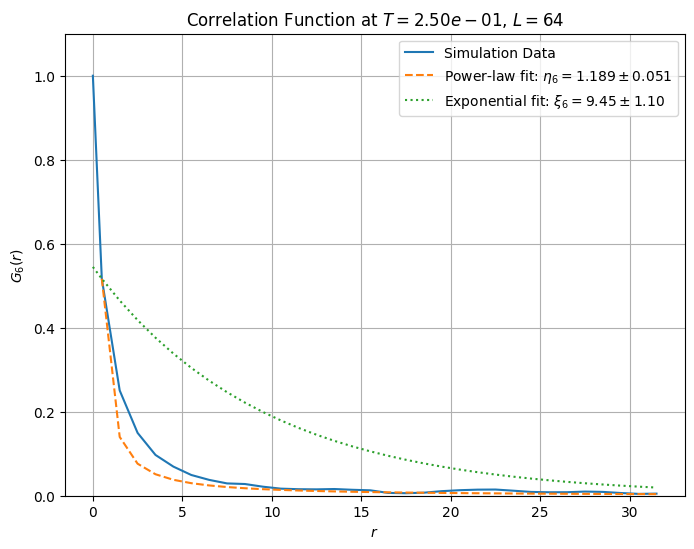

In [32]:
epsilon = 0
gamma = 1.0
rho = 1.0
A = 1.0
T = [10**(-5), 0.01, 0.05, 0.1, 0.12, 0.15, 0.17, 0.18, 0.19, 0.2, 0.21, 0.25]

L=64
n_thermal=2*10**6
n_steps=10**3
measure_interval=10**2
overrelax_interval=10**4

for temp in T:
    sim = Simulation(L=L, T=temp, epsilon=epsilon, gamma=gamma, A=A, rho=rho, n_thermal=n_thermal, n_steps=n_steps, measure_interval=measure_interval, overrelax_interval=overrelax_interval, tune_delta=True)
    sim.run(path="FiguresSmallGrain")

## All parts

## Running Simulation at T=1.00e-05, L=64

### Final Acceptance Rate: 0.016, Delta: 0.189

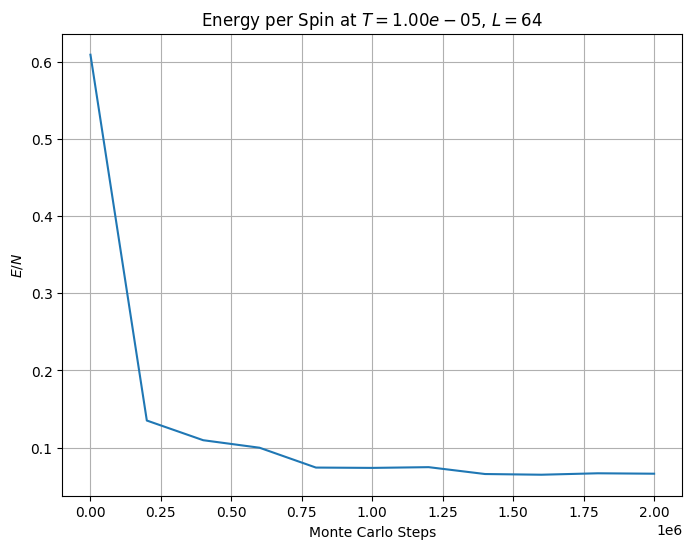

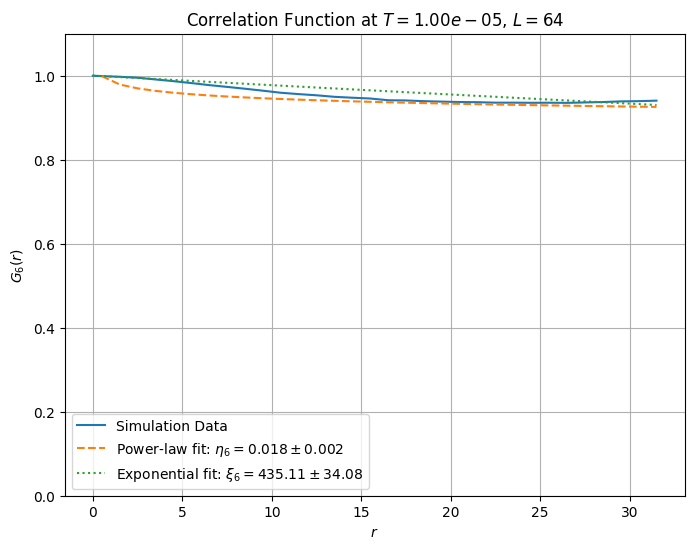

## Running Simulation at T=1.00e-02, L=64

### Final Acceptance Rate: 0.042, Delta: 0.189

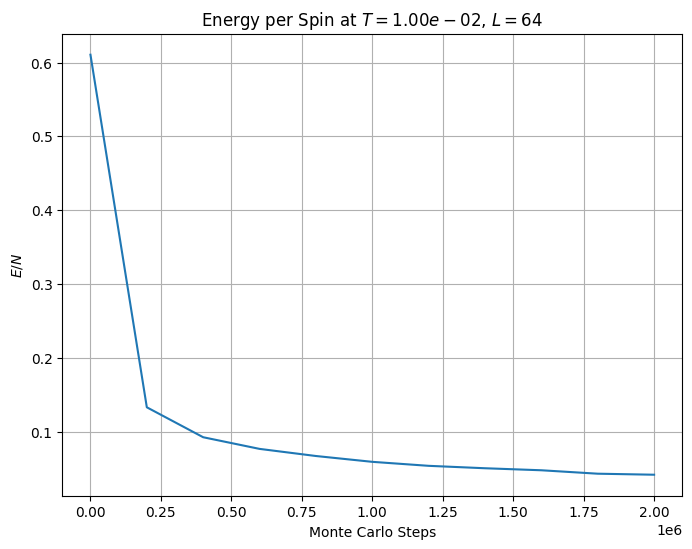

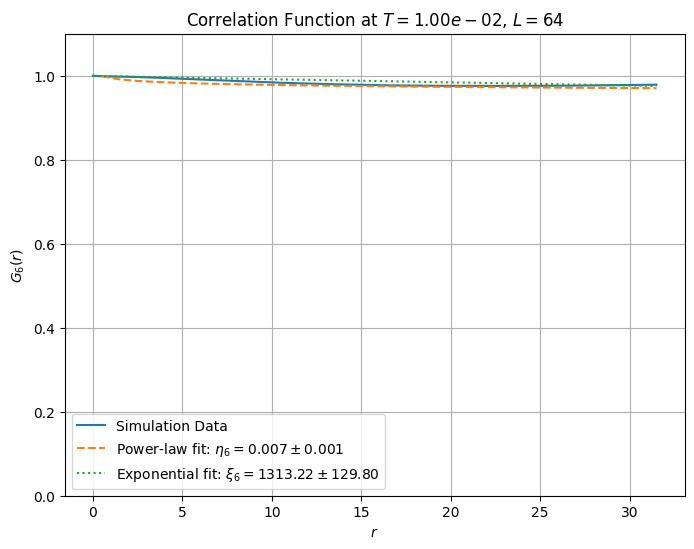

## Running Simulation at T=5.00e-02, L=64

### Final Acceptance Rate: 0.252, Delta: 0.189

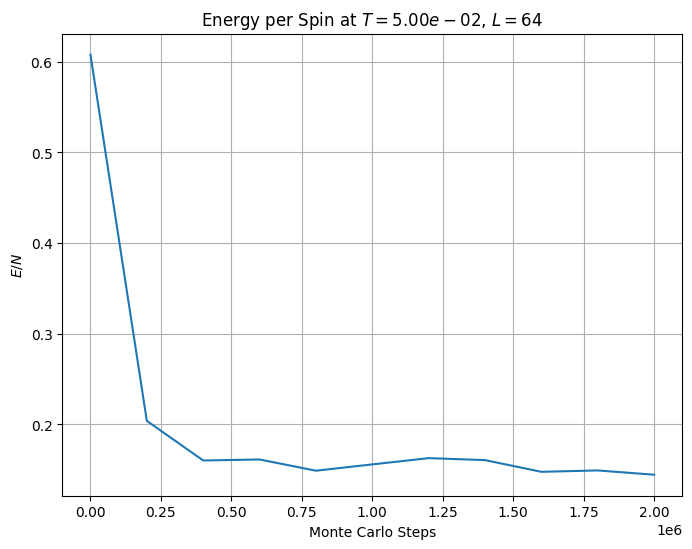

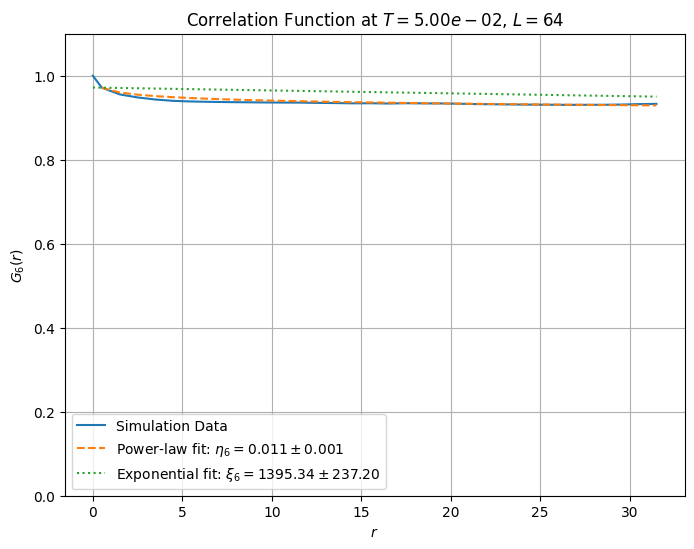

## Running Simulation at T=1.00e-01, L=64

### Final Acceptance Rate: 0.455, Delta: 0.244

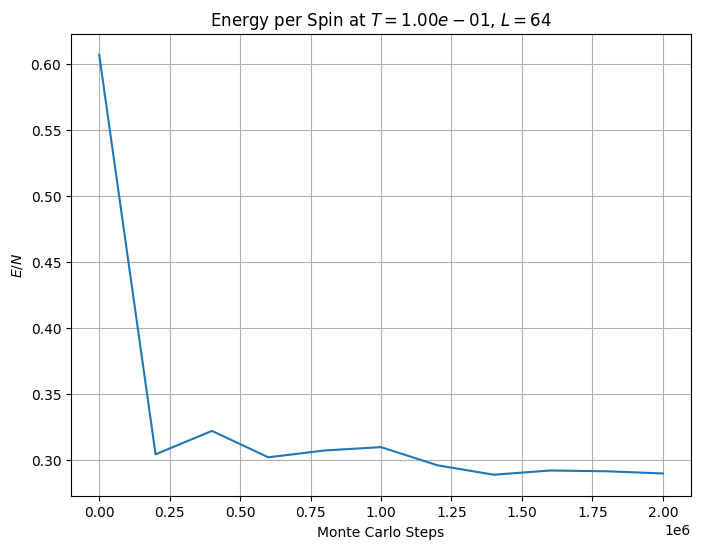

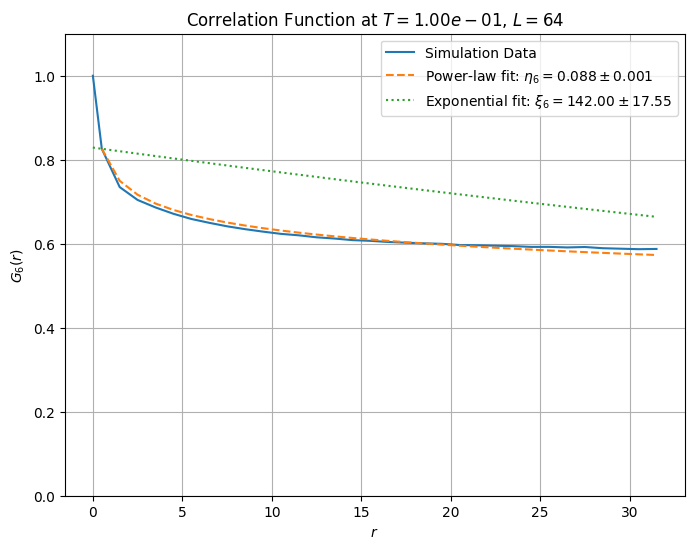

## Running Simulation at T=1.20e-01, L=64

### Final Acceptance Rate: 0.468, Delta: 0.332

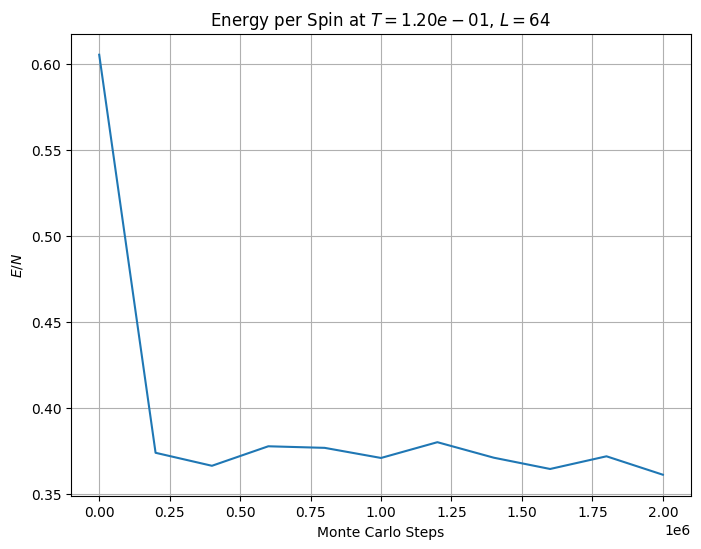

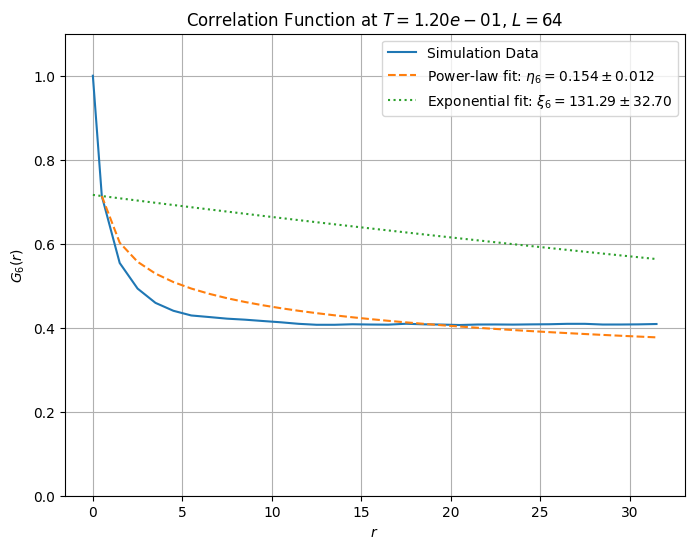

## Running Simulation at T=1.50e-01, L=64

### Final Acceptance Rate: 0.506, Delta: 0.524

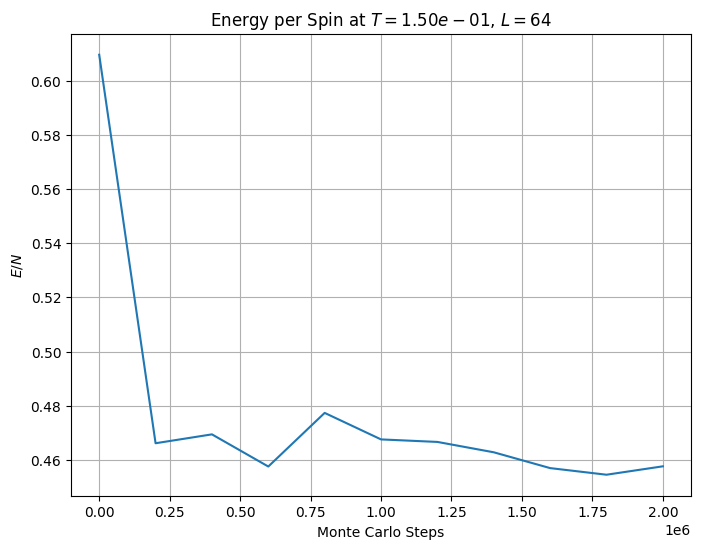

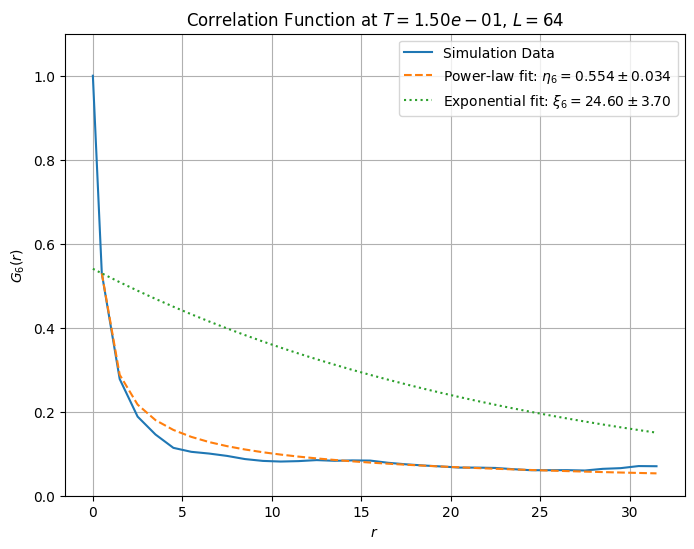

## Running Simulation at T=1.70e-01, L=64

### Final Acceptance Rate: 0.607, Delta: 0.524

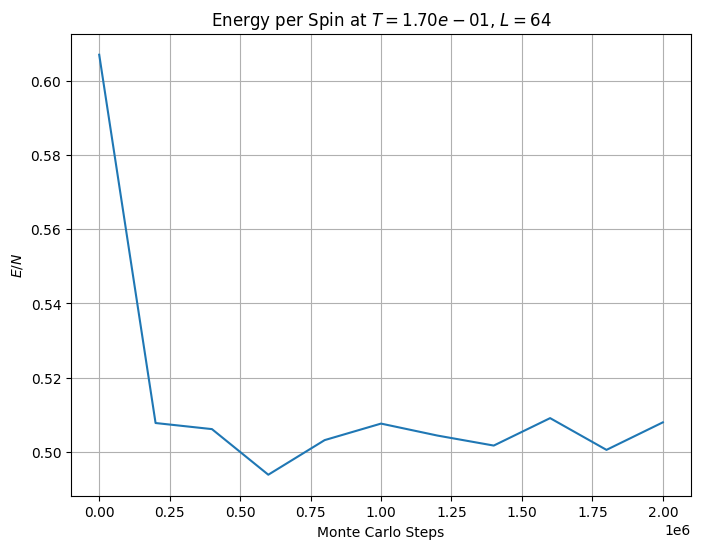

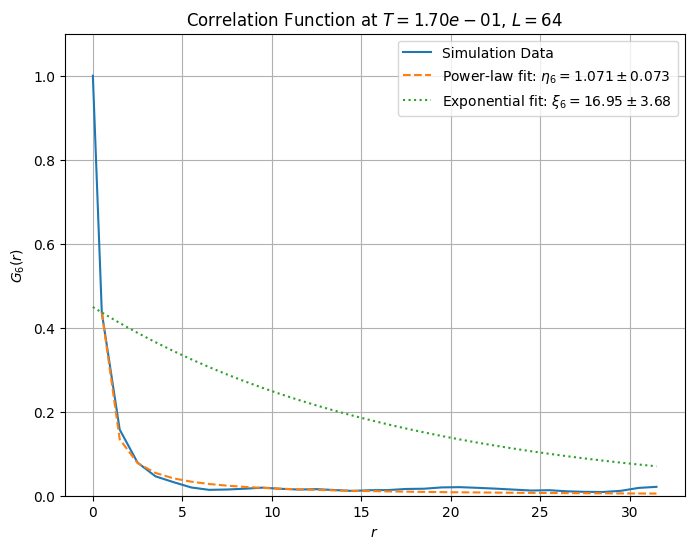

## Running Simulation at T=1.80e-01, L=64

### Final Acceptance Rate: 0.629, Delta: 0.524

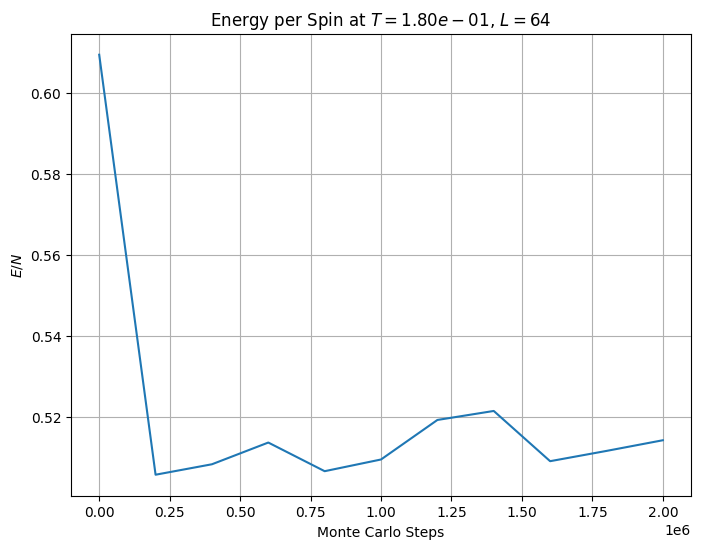

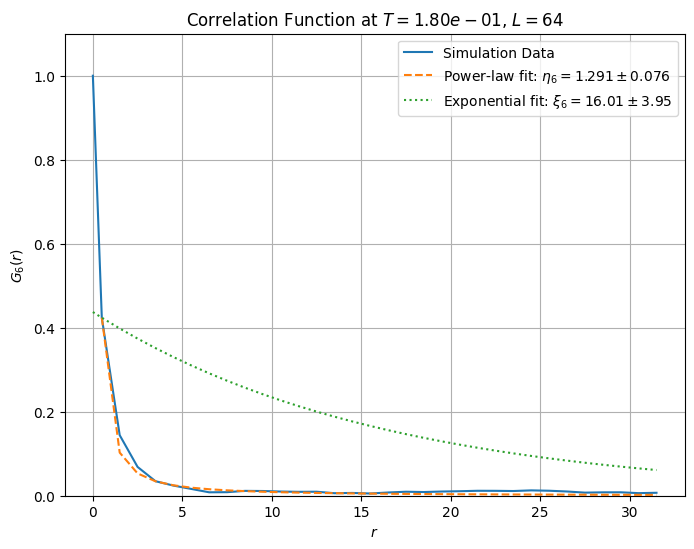

## Running Simulation at T=1.90e-01, L=64

### Final Acceptance Rate: 0.661, Delta: 0.524

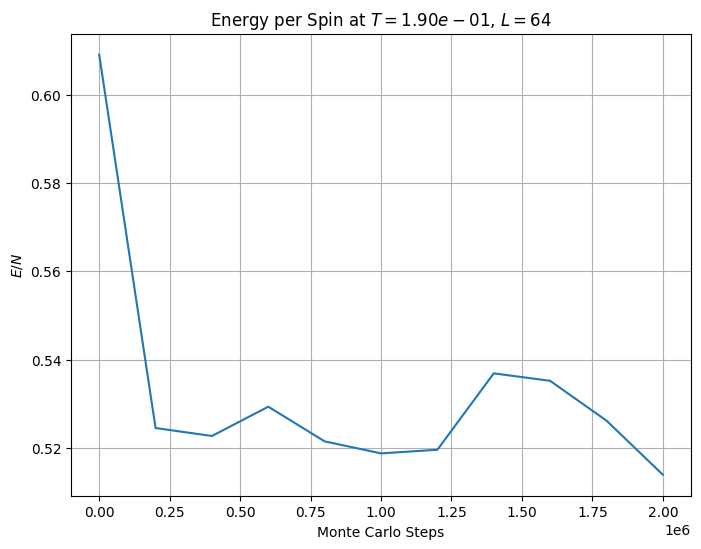

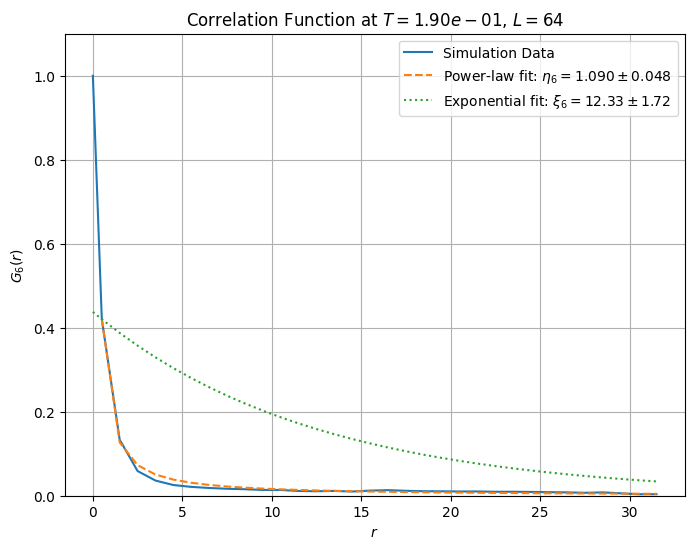

## Running Simulation at T=2.00e-01, L=64

### Final Acceptance Rate: 0.676, Delta: 0.524

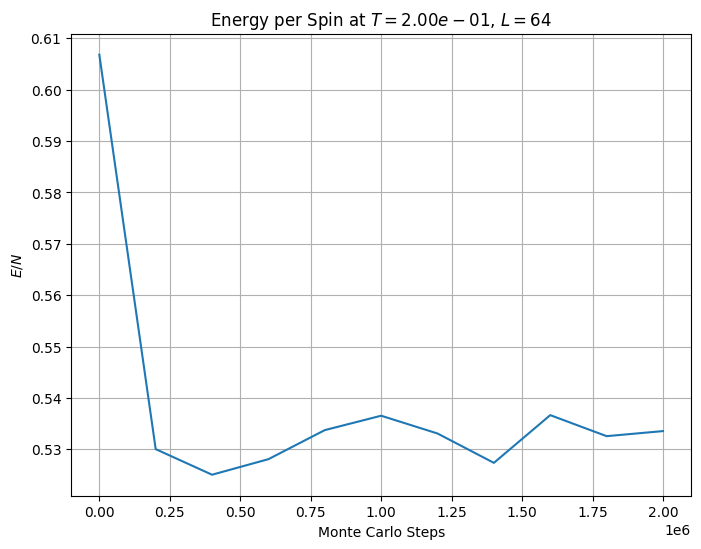

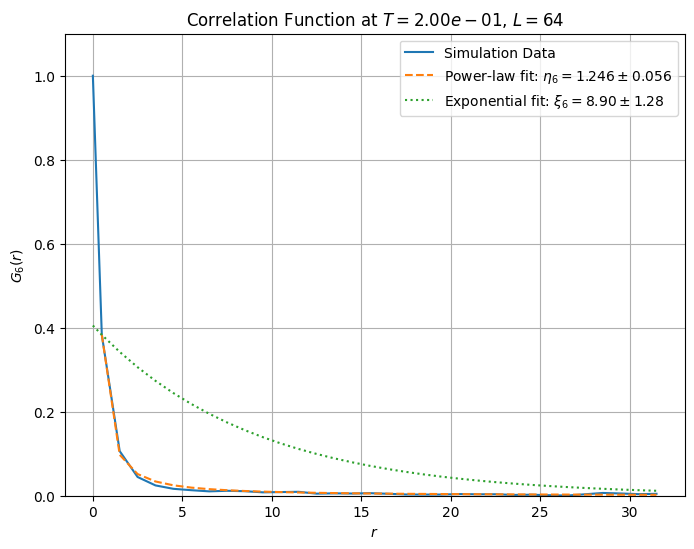

## Running Simulation at T=2.10e-01, L=64

### Final Acceptance Rate: 0.694, Delta: 0.524

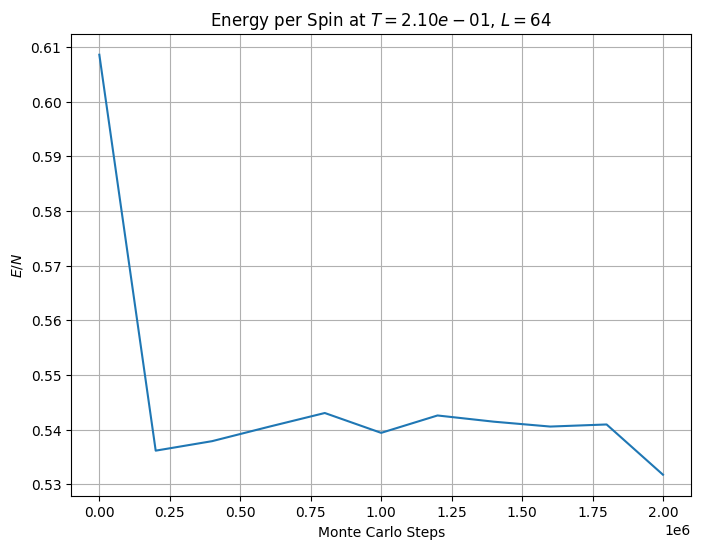

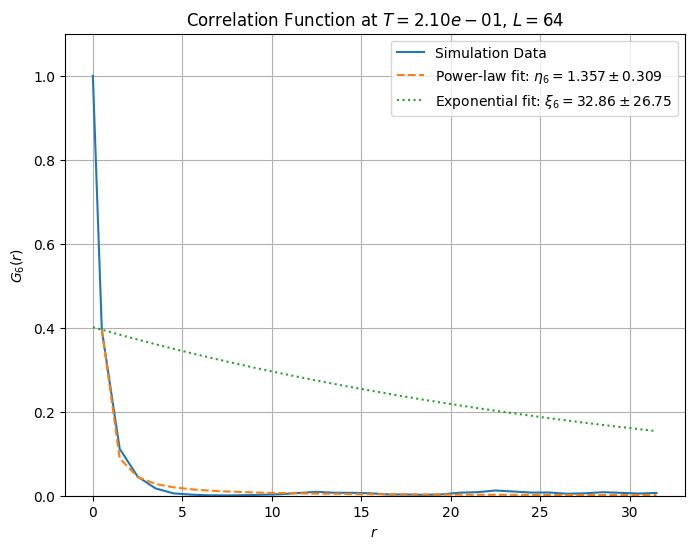

## Running Simulation at T=2.50e-01, L=64

### Final Acceptance Rate: 0.753, Delta: 0.524

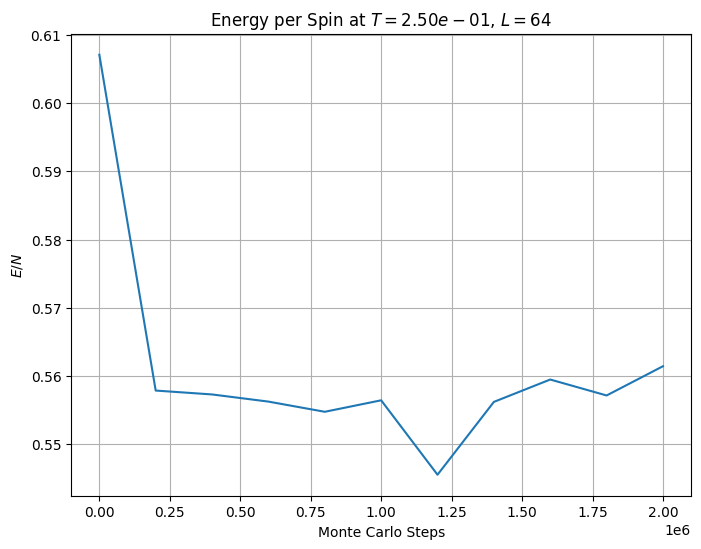

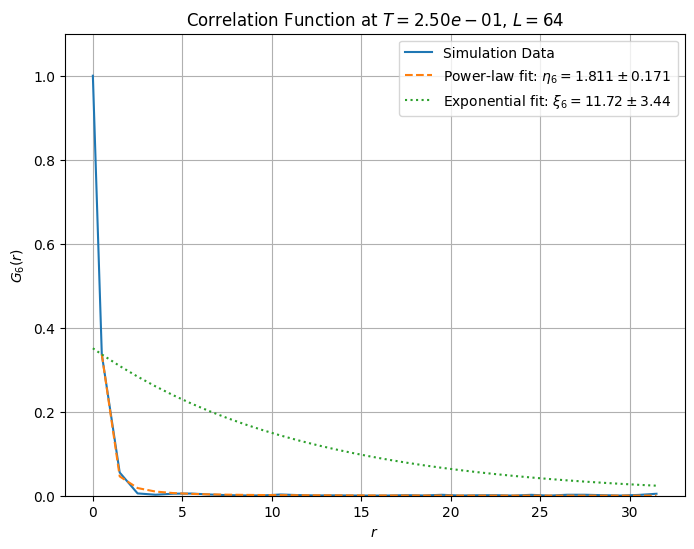

In [33]:
epsilon = 0.5
gamma = 0.5
rho = 1.0
A = 1.0
T = [10**(-5), 0.01, 0.05, 0.1, 0.12, 0.15, 0.17, 0.18, 0.19, 0.2, 0.21, 0.25]

L=64
n_thermal=2*10**6
n_steps=10**3
measure_interval=10**2
overrelax_interval=10**4

for temp in T:
    sim = Simulation(L=L, T=temp, epsilon=epsilon, gamma=gamma, A=A, rho=rho, n_thermal=n_thermal, n_steps=n_steps, measure_interval=measure_interval, overrelax_interval=overrelax_interval, tune_delta=True)
    sim.run(path="FiguresBoth")